# Imports

In [2]:
import sys
from pathlib import Path

current_dir = Path.cwd()
if current_dir.name == "notebooks":
    ROOT = current_dir.parent
else:
    ROOT = current_dir

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Repo root:", ROOT)

Repo root: c:\Users\Navya\Desktop\Quant Projects\derivatives-risk-engine


In [3]:
import sys
from pathlib import Path

current_dir = Path.cwd()
if current_dir.name == "notebooks":
    ROOT = current_dir.parent
else:
    ROOT = current_dir

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits import mplot3d

from src.black_scholes import BlackScholes
from src.utils import get_hist_prices

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load SPY + Options Parameters

In [4]:
ticker = "SPY"
prices = get_hist_prices(ticker, period="5y")
returns = np.log(prices / prices.shift(1)).dropna()

S0 = float(prices.iloc[-1])
sigma_hat = float(returns.std(ddof=1) * np.sqrt(252))
r = 0.03
q = 0.0

K = S0 * 1.0  # ATM strike
T_short = 0.01  # ~2.5 days
T_long = 1.0    # 1 year

print(f"{ticker} S0:", S0)
print(f"Annualized vol:", sigma_hat)
print(f"Option: K={K}, r={r}, q={q}")

SPY S0: 754.8300170898438
Annualized vol: 0.17117595588745632
Option: K=754.8300170898438, r=0.03, q=0.0


# Compute Greeks for Single Option

In [5]:
bs = BlackScholes(S0, K, T_short, r, sigma_hat, q=q)

greeks = bs.greeks()
print("Greeks for ATM option with T=0.01:")
for name, val in greeks.items():
    print(f"  {name}: {val:.6f}")

Greeks for ATM option with T=0.01:
  delta_call: 0.510405
  delta_put: -0.489595
  gamma: 0.030865
  vega: 30.103118
  theta_call: -269.046536
  theta_put: -246.408428
  rho_call: 3.800012
  rho_put: -3.746024
  vanna: -0.020891
  volga: 0.041134


# Delta Surface over (S, T) Space

In [6]:
S_grid = np.linspace(S0 * 0.8, S0 * 1.2, 50)
T_grid = np.linspace(0.01, 1.0, 50)

delta_surface = np.zeros((len(S_grid), len(T_grid)))
gamma_surface = np.zeros((len(S_grid), len(T_grid)))
vega_surface = np.zeros((len(S_grid), len(T_grid)))
theta_surface = np.zeros((len(S_grid), len(T_grid)))
vanna_surface = np.zeros((len(S_grid), len(T_grid)))
volga_surface = np.zeros((len(S_grid), len(T_grid)))

for i, S_val in enumerate(S_grid):
    for j, T_val in enumerate(T_grid):
        bs = BlackScholes(S_val, K, T_val, r, sigma_hat, q=q)
        delta_surface[i, j] = bs.delta('call')
        gamma_surface[i, j] = bs.gamma()
        vega_surface[i, j] = bs.vega()
        theta_surface[i, j] = bs.theta('call')
        vanna_surface[i, j] = bs.vanna()
        volga_surface[i, j] = bs.volga()

# 3D Gamma Surface

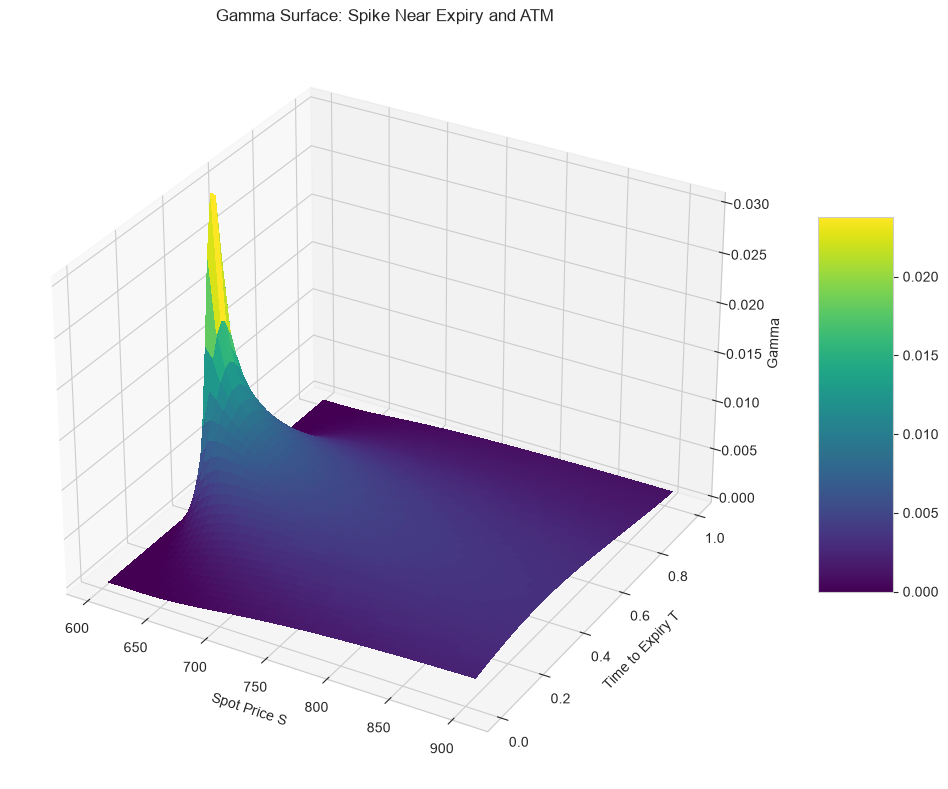

In [7]:
X, Y = np.meshgrid(S_grid, T_grid)
Z = gamma_surface

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)
ax.set_xlabel('Spot Price S')
ax.set_ylabel('Time to Expiry T')
ax.set_zlabel('Gamma')
ax.set_title('Gamma Surface: Spike Near Expiry and ATM')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

# 3D Delta Surface

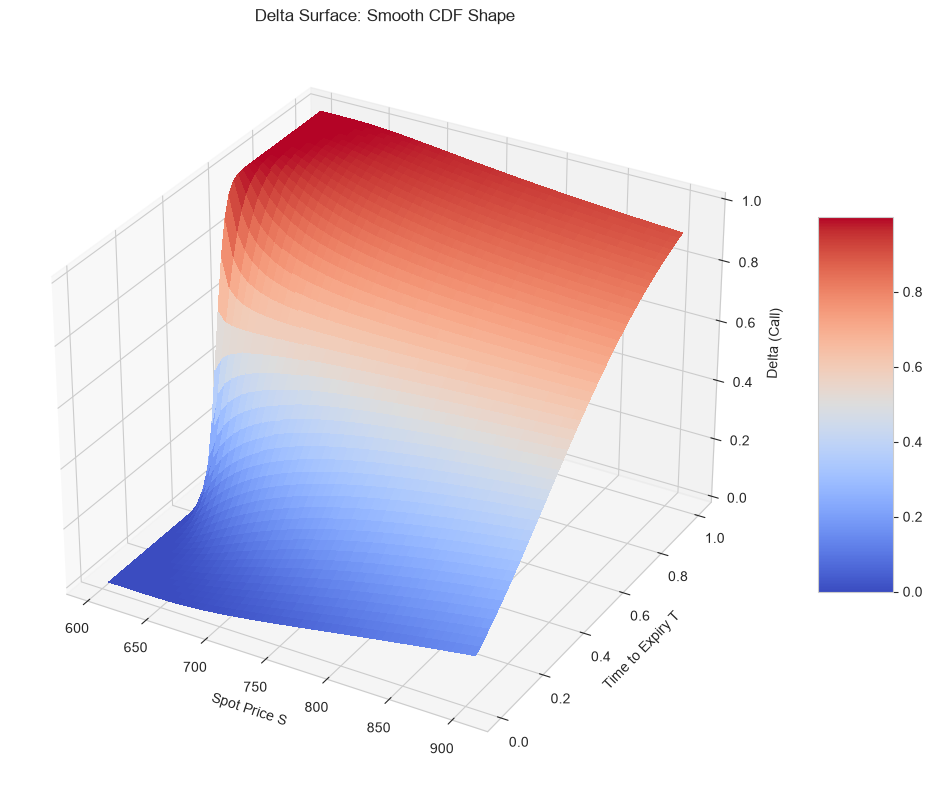

In [8]:
Z = delta_surface

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', linewidth=0, antialiased=False)
ax.set_xlabel('Spot Price S')
ax.set_ylabel('Time to Expiry T')
ax.set_zlabel('Delta (Call)')
ax.set_title('Delta Surface: Smooth CDF Shape')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

# 3D Vega Surface

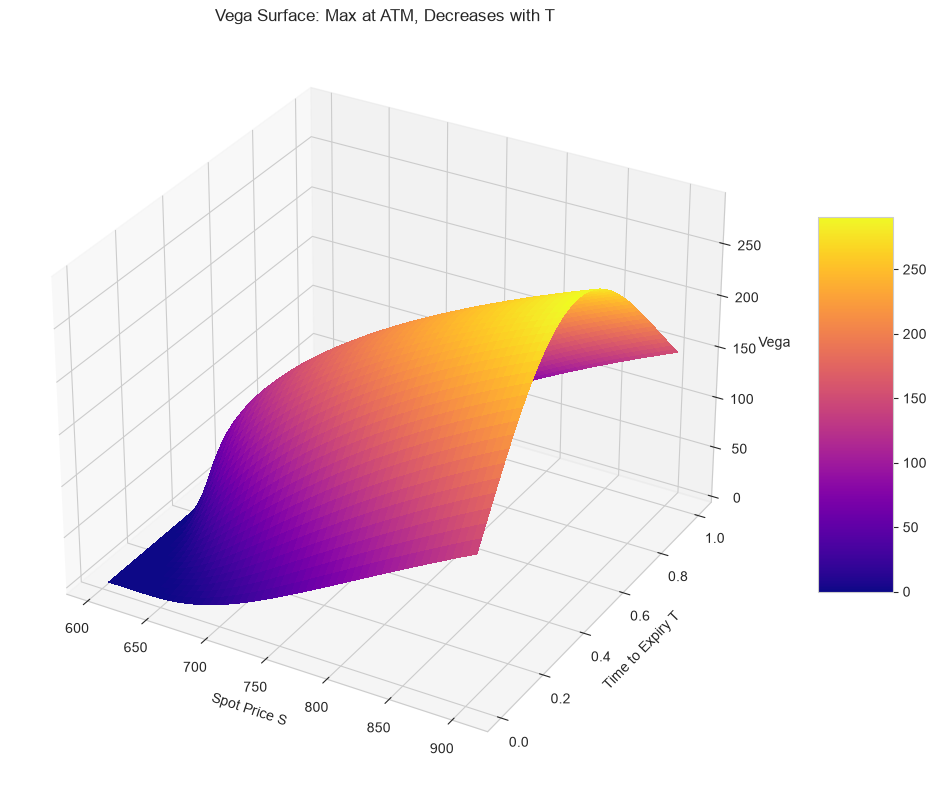

In [9]:
Z = vega_surface

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='plasma', linewidth=0, antialiased=False)
ax.set_xlabel('Spot Price S')
ax.set_ylabel('Time to Expiry T')
ax.set_zlabel('Vega')
ax.set_title('Vega Surface: Max at ATM, Decreases with T')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

# 3D Theta Surface

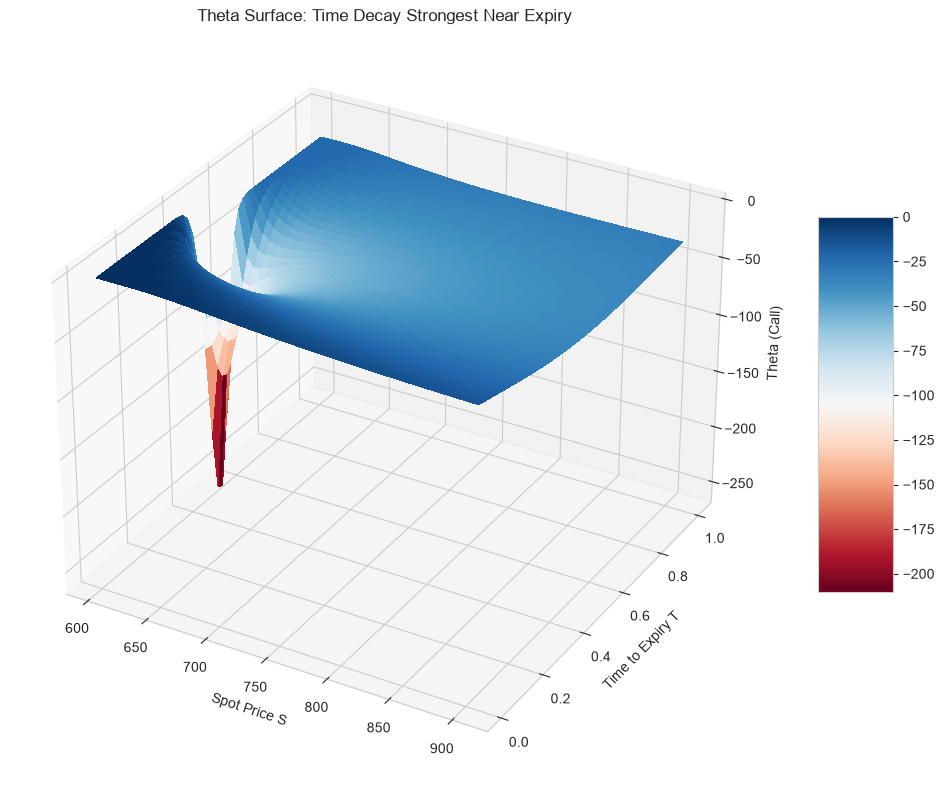

In [10]:
Z = theta_surface

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='RdBu', linewidth=0, antialiased=False)
ax.set_xlabel('Spot Price S')
ax.set_ylabel('Time to Expiry T')
ax.set_zlabel('Theta (Call)')
ax.set_title('Theta Surface: Time Decay Strongest Near Expiry')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

# 3D Vanna Surface

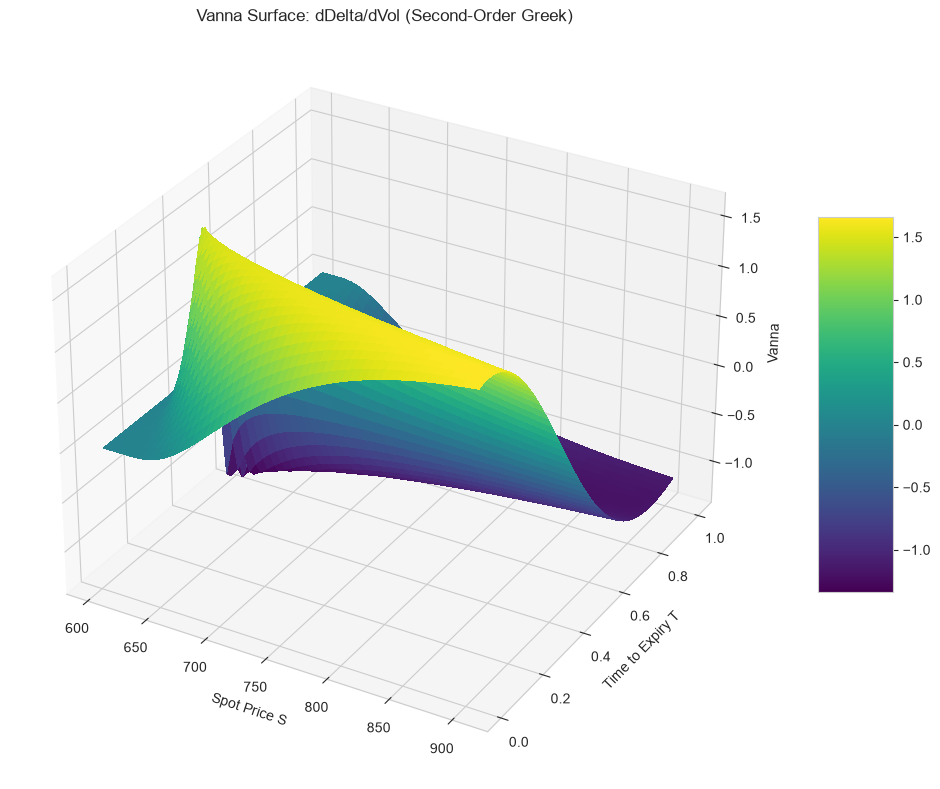


Vanna measures sensitivity of delta to volatility changes.
Used for hedging volatility risk in options books.


In [11]:
Z = vanna_surface

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)
ax.set_xlabel('Spot Price S')
ax.set_ylabel('Time to Expiry T')
ax.set_zlabel('Vanna')
ax.set_title('Vanna Surface: dDelta/dVol (Second-Order Greek)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

# 3D Volga Surface

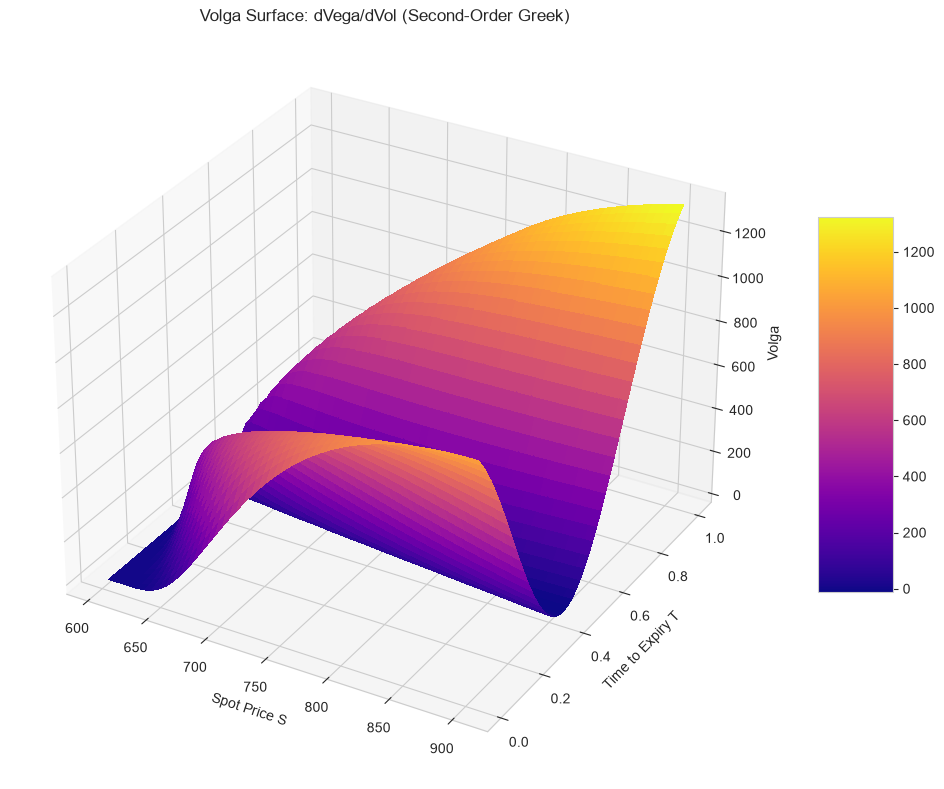


Volga (Vomma) measures sensitivity of vega to volatility changes.
Used for volga hedging in structured products.


In [12]:
Z = volga_surface

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='plasma', linewidth=0, antialiased=False)
ax.set_xlabel('Spot Price S')
ax.set_ylabel('Time to Expiry T')
ax.set_zlabel('Volga')
ax.set_title('Volga Surface: dVega/dVol (Second-Order Greek)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

# 2D Greeks at T = 0.25

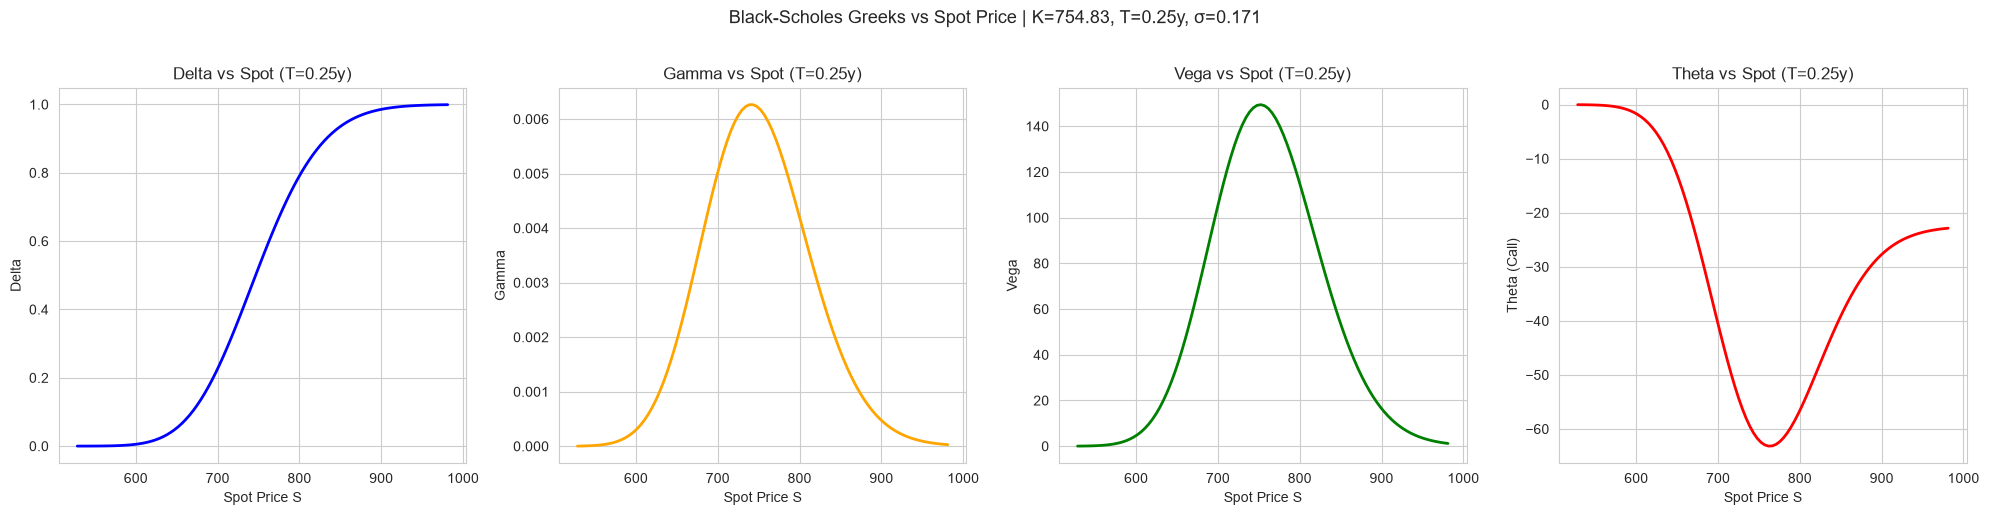

In [15]:
T_fixed = 0.25
S_fixed = np.linspace(S0 * 0.7, S0 * 1.3, 100)

delta_fixed = []
gamma_fixed = []
vega_fixed = []
theta_fixed = []

for S_val in S_fixed:
    bs = BlackScholes(S_val, K, T_fixed, r, sigma_hat, q=q)
    delta_fixed.append(bs.delta('call'))
    gamma_fixed.append(bs.gamma())
    vega_fixed.append(bs.vega())
    theta_fixed.append(bs.theta('call'))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].plot(S_fixed, delta_fixed, color='blue', lw=2)
axes[0].set_xlabel('Spot Price S')
axes[0].set_ylabel('Delta')
axes[0].set_title(f'Delta vs Spot (T={T_fixed:.2f}y)')
axes[0].grid(True)

axes[1].plot(S_fixed, gamma_fixed, color='orange', lw=2)
axes[1].set_xlabel('Spot Price S')
axes[1].set_ylabel('Gamma')
axes[1].set_title(f'Gamma vs Spot (T={T_fixed:.2f}y)')
axes[1].grid(True)

axes[2].plot(S_fixed, vega_fixed, color='green', lw=2)
axes[2].set_xlabel('Spot Price S')
axes[2].set_ylabel('Vega')
axes[2].set_title(f'Vega vs Spot (T={T_fixed:.2f}y)')
axes[2].grid(True)

axes[3].plot(S_fixed, theta_fixed, color='red', lw=2)
axes[3].set_xlabel('Spot Price S')
axes[3].set_ylabel('Theta (Call)')
axes[3].set_title(f'Theta vs Spot (T={T_fixed:.2f}y)')
axes[3].grid(True)

plt.suptitle(f'Black-Scholes Greeks vs Spot Price | K={K:.2f}, T={T_fixed:.2f}y, σ={sigma_hat:.3f}', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()